   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.6 MB/s eta 0:00:00
Shape: (184138, 3)

Таргет:
target
1    95003
0    89135
Name: count, dtype: int64

Процент: 0.516

Пропуски:
hotel_id               0
supplier_room_name    18
target                 0
dtype: int64

Длина текста:
count    184138.000000
mean         76.419408
std          55.492482
min           0.000000
25%          33.000000
50%          58.000000
75%         107.000000
max         250.000000
Name: text_length, dtype: float64

Самые короткие:
      supplier_room_name  text_length  target
26377                NaN            0       1
42380                NaN            0       1
42884                NaN            0       1
43000                NaN            0       1
43324                NaN            0       1
44038                NaN            0       1
44044                NaN            0       1
60035                NaN            0       1
60098                NaN            0       1
60121         

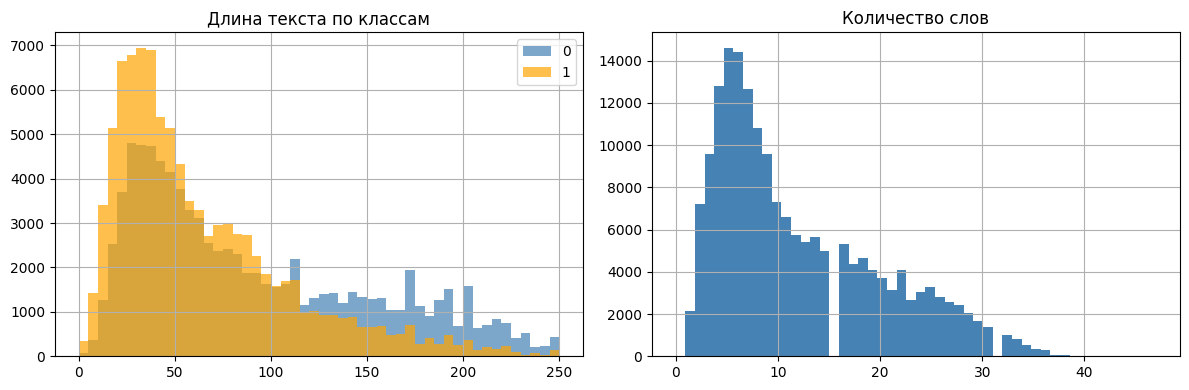

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score, roc_auc_score
!pip install catboost -q
from catboost import CatBoostClassifier, Pool

df = pd.read_csv("/content/public_dataset.csv")

print("Shape:", df.shape)
print("\nТаргет:")
print(df["target"].value_counts())
print(f"\nПроцент: {df['target'].mean():.3f}")
print("\nПропуски:")
print(df.isnull().sum())

# длина текста
df["text_length"] = df["supplier_room_name"].fillna("").apply(len)
df["word_count"]  = df["supplier_room_name"].fillna("").apply(lambda x: len(x.split()))

print("\nДлина текста:")
print(df["text_length"].describe())

print("\nСамые короткие:")
print(df.nsmallest(10, "text_length")[["supplier_room_name", "text_length", "target"]])

# распределение по классам
print("\nСредняя длина по классам:")
print(df.groupby("target")[["text_length", "word_count"]].mean().round(2))

# график
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
df[df["target"]==0]["text_length"].hist(bins=50, alpha=0.7, color="steelblue", label="0")
df[df["target"]==1]["text_length"].hist(bins=50, alpha=0.7, color="orange", label="1")
plt.title("Длина текста по классам")
plt.legend()
plt.subplot(1, 2, 2)
df["word_count"].hist(bins=50, color="steelblue")
plt.title("Количество слов")
plt.tight_layout()
plt.show()

In [2]:
from sklearn.model_selection import train_test_split

# random split — отели пересекаются, hotel фичи работают
df_train_val, df_test = train_test_split(
    df, test_size=0.15, random_state=42, stratify=df["target"]
)
df_train, df_val = train_test_split(
    df_train_val, test_size=0.15, random_state=42, stratify=df_train_val["target"]
)

print(f"Train: {len(df_train)} строк")
print(f"Val:   {len(df_val)} строк")
print(f"Test:  {len(df_test)} строк")
print(f"\nТаргет train: {df_train['target'].mean():.3f}")
print(f"Таргет val:   {df_val['target'].mean():.3f}")
print(f"Таргет test:  {df_test['target'].mean():.3f}")

# проверка пересечений
train_keys = set(zip(df_train["hotel_id"], df_train["supplier_room_name"]))
test_keys  = set(zip(df_test["hotel_id"],  df_test["supplier_room_name"]))
overlap    = train_keys & test_keys
print(f"\nПересечений train/test: {len(overlap)} ({len(overlap)/len(test_keys)*100:.1f}%)")

Train: 133039 строк
Val:   23478 строк
Test:  27621 строк

Таргет train: 0.516
Таргет val:   0.516
Таргет test:  0.516

Пересечений train/test: 69 (0.2%)


In [3]:
def preprocess_text(text):
    if not isinstance(text, str) or text.strip() == "":
        return None

    original = text.strip()

    # убираем если это просто цифры или мусор
    if re.fullmatch(r'[\d\s\W]+', original):
        return None

    # нижний регистр
    text = original.lower()

    # убираем лишние символы — оставляем буквы обоих языков, цифры, пробелы
    text = re.sub(r'[^a-zа-яёa-zа-яё0-9\s]', ' ', text)

    # убираем множественные пробелы
    text = re.sub(r'\s+', ' ', text).strip()

    # минимум 2 слова
    if len(text.split()) < 2:
        return None

    return text

df_train["text_clean"] = df_train["supplier_room_name"].apply(preprocess_text)
df_val["text_clean"]   = df_val["supplier_room_name"].apply(preprocess_text)
df_test["text_clean"]  = df_test["supplier_room_name"].apply(preprocess_text)
before_train = len(df_train)
before_val   = len(df_val)

df_train = df_train.dropna(subset=["text_clean"]).copy()
df_val   = df_val.dropna(subset=["text_clean"]).copy()

df_test["text_clean"] = df_test["text_clean"].fillna("")

print(f"Train: {before_train} → {len(df_train)} (удалено {before_train - len(df_train)})")
print(f"Val:   {before_val} → {len(df_val)} (удалено {before_val - len(df_val)})")
print(f"Test:  {len(df_test)} (не меняем)")

# удаляем полные дубликаты из трейна
before = len(df_train)
df_train = df_train.drop_duplicates(
    subset=["hotel_id", "supplier_room_name", "target"]
).copy()
print(f"\nДубликаты удалены из трейна: {before} → {len(df_train)}")

# конфликтующие дубликаты оставляем
conflicts = df_train.groupby(
    ["hotel_id", "supplier_room_name"]
)["target"].nunique()
print(f"Конфликтующих пар оставлено: {(conflicts > 1).sum()}")

# проверка
print("\nПримеры до/после предобработки:")
sample = df_train.sample(5, random_state=42)
for _, row in sample.iterrows():
    print(f"  До:    {row['supplier_room_name']}")
    print(f"  После: {row['text_clean']}")
    print()

Train: 133039 → 131606 (удалено 1433)
Val:   23478 → 23214 (удалено 264)
Test:  27621 (не меняем)

Дубликаты удалены из трейна: 131606 → 131606
Конфликтующих пар оставлено: 163

Примеры до/после предобработки:
  До:    Room Capacity 1
  После: room capacity 1

  До:    4 Bed Xl Terrace Pool Suite (4 Bed Residence Sea View Private Pool)
  После: 4 bed xl terrace pool suite 4 bed residence sea view private pool

  До:    room assigned on arrival 
  После: room assigned on arrival

  До:    Номер Palmscape (питание для детей не включено, дополнительные кровати не включены, терраса)
  После: номер palmscape питание для детей не включено дополнительные кровати не включены терраса

  До:    Двухместный номер Superior с видом на море (двуспальная кровать) (дополнительная кровать включена)
  После: двухместный номер superior с видом на море двуспальная кровать дополнительная кровать включена



In [4]:
# считаем на трейне
hotel_stats = df_train.groupby("hotel_id")["target"].agg(
    hotel_positive_rate="mean",
    hotel_room_count="count",
    hotel_target_std="std"
).reset_index()
hotel_stats["hotel_target_std"] = hotel_stats["hotel_target_std"].fillna(0)

df_train = df_train.merge(hotel_stats, on="hotel_id", how="left")
df_val   = df_val.merge(hotel_stats,   on="hotel_id", how="left")
df_test  = df_test.merge(hotel_stats,  on="hotel_id", how="left")

# новые отели — заполняем глобальным средним
global_mean = df_train["target"].mean()
for df_ in [df_val, df_test]:
    df_["hotel_positive_rate"] = df_["hotel_positive_rate"].fillna(global_mean)
    df_["hotel_room_count"]    = df_["hotel_room_count"].fillna(0)
    df_["hotel_target_std"]    = df_["hotel_target_std"].fillna(0)

print("Hotel фичи готовы")
print(f"\nHotel positive rate по сетам:")
print(f"Train: {df_train['hotel_positive_rate'].mean():.3f}")
print(f"Val:   {df_val['hotel_positive_rate'].mean():.3f}")
print(f"Test:  {df_test['hotel_positive_rate'].mean():.3f}")

Hotel фичи готовы

Hotel positive rate по сетам:
Train: 0.512
Val:   0.510
Test:  0.510


In [5]:
def add_features(df_):
    df_   = df_.copy()
    text  = df_["text_clean"].fillna("")
    orig  = df_["supplier_room_name"].fillna("")

    # базовые
    df_["text_length"]     = orig.apply(len)
    df_["word_count"]      = text.apply(lambda x: len(x.split()))
    df_["unique_ratio"]    = text.apply(
        lambda x: len(set(x.split())) / max(len(x.split()), 1)
    )
    df_["upper_ratio"]     = orig.apply(
        lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1)
    )
    df_["has_parentheses"] = orig.apply(lambda x: int("(" in x))
    df_["digit_count"]     = orig.apply(
        lambda x: sum(1 for c in x if c.isdigit())
    )

    # языковые
    df_["ru_ratio"] = text.apply(
        lambda x: sum(1 for c in x if 'а' <= c <= 'я' or c == 'ё') / max(len(x), 1)
    )
    df_["en_ratio"] = text.apply(
        lambda x: sum(1 for c in x if 'a' <= c <= 'z') / max(len(x), 1)
    )

    # бизнес фичи
    bed_configs = [
        "king", "queen", "twin", "double", "single", "bunk",
        "двуспальн", "односпальн", "1 bed", "2 bed",
        "1 кровать", "2 кровати", "2 отдельные"
    ]
    df_["has_bed_config"] = text.apply(
        lambda x: int(any(b in x for b in bed_configs))
    )

    room_levels = [
        "standard", "стандарт", "deluxe", "делюкс",
        "superior", "executive", "premium", "премиум",
        "classic", "comfort", "комфорт", "люкс", "economy"
    ]
    df_["has_room_level"] = text.apply(
        lambda x: int(any(r in x for r in room_levels))
    )

    view_words = [
        "sea view", "ocean view", "вид на море",
        "city view", "вид на город", "garden view",
        "pool view", "mountain view", " view", " вид"
    ]
    df_["has_view"] = text.apply(
        lambda x: int(any(v in x for v in view_words))
    )

    balcony_words = ["balcon", "terrace", "террас", "балкон", "лоджия"]
    df_["has_balcony"] = text.apply(
        lambda x: int(any(b in x for b in balcony_words))
    )

    family_words = ["family", "семейн", "child", "детск", "kids"]
    df_["is_family"] = text.apply(
        lambda x: int(any(f in x for f in family_words))
    )

    # бизнес score — сколько характеристик упомянуто
    biz = ["has_bed_config", "has_room_level", "has_view",
           "has_balcony", "is_family"]
    df_["business_completeness"] = df_[biz].sum(axis=1) / len(biz)

    return df_

df_train = add_features(df_train)
df_val   = add_features(df_val)
df_test  = add_features(df_test)

print("Фичи добавлены")
print(f"Колонок: {len(df_train.columns)}")

feature_cols = [
    "text_length", "word_count", "unique_ratio", "upper_ratio",
    "has_parentheses", "digit_count", "ru_ratio", "en_ratio",
    "has_bed_config", "has_room_level", "has_view",
    "has_balcony", "is_family", "business_completeness",
    "hotel_positive_rate", "hotel_room_count", "hotel_target_std"
]

print("\nФичи по классам:")
print(df_train.groupby("target")[feature_cols].mean().round(3).T)

Фичи добавлены
Колонок: 21

Фичи по классам:
target                       0        1
text_length             90.671   64.353
word_count              13.641    9.917
unique_ratio             0.860    0.919
upper_ratio              0.080    0.110
has_parentheses          0.549    0.392
digit_count              0.619    0.769
ru_ratio                 0.210    0.173
en_ratio                 0.635    0.672
has_bed_config           0.766    0.698
has_room_level           0.618    0.553
has_view                 0.300    0.301
has_balcony              0.121    0.088
is_family                0.340    0.179
business_completeness    0.429    0.364
hotel_positive_rate      0.379    0.639
hotel_room_count       940.430  777.601
hotel_target_std         0.448    0.358


In [6]:
X_train = df_train[feature_cols + ["text_clean"]].fillna("")
X_val   = df_val[feature_cols   + ["text_clean"]].fillna("")
y_train = df_train["target"]
y_val   = df_val["target"]

train_pool = Pool(data=X_train, label=y_train, text_features=["text_clean"])
val_pool   = Pool(data=X_val,   label=y_val,   text_features=["text_clean"])

print("Обучаем CatBoost...")
model_cb = CatBoostClassifier(
    iterations=3000,
    learning_rate=0.03,   # меньше чем раньше — меньше риск оверфита
    depth=6,
    eval_metric="AUC",
    random_seed=42,
    verbose=200,
    l2_leaf_reg=5,        # регуляризация против оверфита
    min_data_in_leaf=20,  # минимум данных в листе
)

model_cb.fit(train_pool, eval_set=val_pool, early_stopping_rounds=150)

y_val_proba = model_cb.predict_proba(val_pool)[:, 1]
pr_auc  = average_precision_score(y_val, y_val_proba)
roc_auc = roc_auc_score(y_val, y_val_proba)

print(f"\nPR-AUC:  {pr_auc:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

# важность фичей
importance = model_cb.get_feature_importance()
names      = feature_cols + ["text_clean"]
imp_df = pd.DataFrame({"feature": names, "importance": importance})
imp_df = imp_df.sort_values("importance", ascending=False)
print("\nТоп фичей:")
print(imp_df.head(10).to_string())

Обучаем CatBoost...
0:	test: 0.8271760	best: 0.8271760 (0)	total: 564ms	remaining: 28m 12s
200:	test: 0.9052335	best: 0.9052335 (200)	total: 1m 38s	remaining: 22m 53s
400:	test: 0.9199400	best: 0.9199400 (400)	total: 3m 7s	remaining: 20m 17s
600:	test: 0.9294631	best: 0.9294631 (600)	total: 4m 39s	remaining: 18m 35s
800:	test: 0.9355333	best: 0.9355333 (800)	total: 6m 11s	remaining: 17m 1s
1000:	test: 0.9399038	best: 0.9399038 (1000)	total: 7m 44s	remaining: 15m 27s
1200:	test: 0.9431579	best: 0.9431579 (1200)	total: 9m 14s	remaining: 13m 51s
1400:	test: 0.9459489	best: 0.9459489 (1400)	total: 10m 46s	remaining: 12m 18s
1600:	test: 0.9481259	best: 0.9481259 (1600)	total: 12m 19s	remaining: 10m 46s
1800:	test: 0.9499359	best: 0.9499359 (1800)	total: 13m 53s	remaining: 9m 14s
2000:	test: 0.9514402	best: 0.9514459 (1997)	total: 15m 27s	remaining: 7m 42s
2200:	test: 0.9527197	best: 0.9527197 (2200)	total: 17m 2s	remaining: 6m 11s
2400:	test: 0.9537538	best: 0.9537665 (2397)	total: 18m 35s	

In [7]:
import pickle

with open('model_cb_final.pkl', 'wb') as f:
    pickle.dump(model_cb, f)

with open('feature_cols.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

np.save('y_val_proba_cb_final.npy', y_val_proba)
np.save('y_val_true.npy', y_val.values)

print('Модель CatBoost, список признаков и предсказания сохранены')

Модель CatBoost, список признаков и предсказания сохранены


In [8]:
df = pd.read_csv("/content/public_dataset.csv")

BERT_OOF_PATH = "/content/test_bert_probs.npy"

bert_probs_raw = np.load(BERT_OOF_PATH)

# Проверка совпадения размерностей
if len(bert_probs_raw) == len(df):
    df["bert_prob"] = bert_probs_raw
else:
    print(f"Внимание: размерность массива BERT ({len(bert_probs_raw)}) не совпадает с df ({len(df)}).")
    df["bert_prob"] = 0.5
    df.iloc[:len(bert_probs_raw), df.columns.get_loc("bert_prob")] = bert_probs_raw

print("Shape датасета:", df.shape)
print("\nТаргет:")
print(df["target"].value_counts())
print(f"\nПроцент позитивного класса: {df['target'].mean():.3f}")

# Длина текста
df["text_length"] = df["supplier_room_name"].fillna("").apply(len)
df["word_count"]  = df["supplier_room_name"].fillna("").apply(lambda x: len(x.split()))

df_train_val, df_test = train_test_split(
    df, test_size=0.15, random_state=42, stratify=df["target"]
)
df_train, df_val = train_test_split(
    df_train_val, test_size=0.15, random_state=42, stratify=df_train_val["target"]
)

print(f"\nTrain: {len(df_train)} строк")
print(f"Val:   {len(df_val)} строк")
print(f"Test:  {len(df_test)} строк")

# Предобработка текста
def preprocess_text(text):
    if not isinstance(text, str) or text.strip() == "":
        return None
    original = text.strip()
    if re.fullmatch(r'[\d\s\W]+', original):
        return None
    text = original.lower()
    text = re.sub(r'[^a-zа-яё0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    if len(text.split()) < 2:
        return None
    return text

df_train["text_clean"] = df_train["supplier_room_name"].apply(preprocess_text)
df_val["text_clean"]   = df_val["supplier_room_name"].apply(preprocess_text)
df_test["text_clean"]  = df_test["supplier_room_name"].apply(preprocess_text)

df_train = df_train.dropna(subset=["text_clean"]).copy()
df_val   = df_val.dropna(subset=["text_clean"]).copy()
df_test["text_clean"] = df_test["text_clean"].fillna("")

df_train = df_train.drop_duplicates(
    subset=["hotel_id", "supplier_room_name", "target"]
).copy()

hotel_stats = df_train.groupby("hotel_id")["target"].agg(
    hotel_positive_rate="mean",
    hotel_room_count="count",
    hotel_target_std="std"
).reset_index()
hotel_stats["hotel_target_std"] = hotel_stats["hotel_target_std"].fillna(0)

df_train = df_train.merge(hotel_stats, on="hotel_id", how="left")
df_val   = df_val.merge(hotel_stats,   on="hotel_id", how="left")
df_test  = df_test.merge(hotel_stats,  on="hotel_id", how="left")

global_mean = df_train["target"].mean()
for df_ in [df_val, df_test]:
    df_["hotel_positive_rate"] = df_["hotel_positive_rate"].fillna(global_mean)
    df_["hotel_room_count"]    = df_["hotel_room_count"].fillna(0)
    df_["hotel_target_std"]    = df_["hotel_target_std"].fillna(0)

def add_features(df_):
    df_   = df_.copy()
    text  = df_["text_clean"].fillna("")
    orig  = df_["supplier_room_name"].fillna("")

    df_["text_length"]     = orig.apply(len)
    df_["word_count"]      = text.apply(lambda x: len(x.split()))
    df_["unique_ratio"]    = text.apply(lambda x: len(set(x.split())) / max(len(x.split()), 1))
    df_["upper_ratio"]     = orig.apply(lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1))
    df_["has_parentheses"] = orig.apply(lambda x: int("(" in x))
    df_["digit_count"]     = orig.apply(lambda x: sum(1 for c in x if c.isdigit()))

    df_["ru_ratio"] = text.apply(lambda x: sum(1 for c in x if 'а' <= c <= 'я' or c == 'ё') / max(len(x), 1))
    df_["en_ratio"] = text.apply(lambda x: sum(1 for c in x if 'a' <= c <= 'z') / max(len(x), 1))

    bed_configs = ["king", "queen", "twin", "double", "single", "bunk", "двуспальн", "односпальн", "1 bed", "2 bed", "1 кровать", "2 кровати", "2 отдельные"]
    df_["has_bed_config"] = text.apply(lambda x: int(any(b in x for b in bed_configs)))

    room_levels = ["standard", "стандарт", "deluxe", "делюкс", "superior", "executive", "premium", "премиум", "classic", "comfort", "комфорт", "люкс", "economy"]
    df_["has_room_level"] = text.apply(lambda x: int(any(r in x for r in room_levels)))

    view_words = ["sea view", "ocean view", "вид на море", "city view", "вид на город", "garden view", "pool view", "mountain view", " view", " вид"]
    df_["has_view"] = text.apply(lambda x: int(any(v in x for v in view_words)))

    balcony_words = ["balcon", "terrace", "террас", "балкон", "лоджия"]
    df_["has_balcony"] = text.apply(lambda x: int(any(b in x for b in balcony_words)))

    family_words = ["family", "семейн", "child", "детск", "kids"]
    df_["is_family"] = text.apply(lambda x: int(any(f in x for f in family_words)))

    biz = ["has_bed_config", "has_room_level", "has_view", "has_balcony", "is_family"]
    df_["business_completeness"] = df_[biz].sum(axis=1) / len(biz)

    return df_

df_train = add_features(df_train)
df_val   = add_features(df_val)
df_test  = add_features(df_test)

feature_cols = [
    "bert_prob",
    "text_length", "word_count", "unique_ratio", "upper_ratio",
    "has_parentheses", "digit_count", "ru_ratio", "en_ratio",
    "has_bed_config", "has_room_level", "has_view",
    "has_balcony", "is_family", "business_completeness",
    "hotel_positive_rate", "hotel_room_count", "hotel_target_std"
]

X_train = df_train[feature_cols + ["text_clean"]].fillna(0)
X_val   = df_val[feature_cols   + ["text_clean"]].fillna(0)
y_train = df_train["target"]
y_val   = df_val["target"]

train_pool = Pool(data=X_train, label=y_train, text_features=["text_clean"])
val_pool   = Pool(data=X_val,   label=y_val,   text_features=["text_clean"])

print("\n Обучение CatBoost (Stacked)")
model_cb = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.03,
    depth=6,
    eval_metric="AUC",
    random_seed=42,
    verbose=200,
    l2_leaf_reg=5,
    min_data_in_leaf=20,
)

model_cb.fit(train_pool, eval_set=val_pool, early_stopping_rounds=150)

y_val_proba = model_cb.predict_proba(val_pool)[:, 1]
pr_auc  = average_precision_score(y_val, y_val_proba)
roc_auc = roc_auc_score(y_val, y_val_proba)

print(f"\n Новый PR-AUC CatBoost:  {pr_auc:.4f}")
print(f"Новый ROC-AUC CatBoost: {roc_auc:.4f}")

importance = model_cb.get_feature_importance()
names      = feature_cols + ["text_clean"]
imp_df = pd.DataFrame({"feature": names, "importance": importance}).sort_values("importance", ascending=False)
print("\nТоп фичей в новой модели:")
print(imp_df.head(10).to_string())

with open('model_cb_stacked.pkl', 'wb') as f:
    pickle.dump(model_cb, f)

with open('feature_cols_stacked.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

np.save('y_val_proba_cb_stacked.npy', y_val_proba)
print('\n Модель CatBoost (Stacked) сохранена в /content/')

Внимание: размерность массива BERT (11000) не совпадает с df (184138).
Shape датасета: (184138, 4)

Таргет:
target
1    95003
0    89135
Name: count, dtype: int64

Процент позитивного класса: 0.516

Train: 133039 строк
Val:   23478 строк
Test:  27621 строк

 Обучение CatBoost (Stacked)
0:	test: 0.8347881	best: 0.8347881 (0)	total: 530ms	remaining: 17m 40s
200:	test: 0.9188978	best: 0.9188978 (200)	total: 1m 35s	remaining: 14m 14s
400:	test: 0.9327521	best: 0.9327521 (400)	total: 3m 5s	remaining: 12m 18s
600:	test: 0.9413835	best: 0.9413835 (600)	total: 4m 36s	remaining: 10m 43s
800:	test: 0.9469831	best: 0.9469831 (800)	total: 6m 8s	remaining: 9m 11s
1000:	test: 0.9509932	best: 0.9509932 (1000)	total: 7m 40s	remaining: 7m 39s
1200:	test: 0.9540128	best: 0.9540128 (1200)	total: 9m 12s	remaining: 6m 7s
1400:	test: 0.9564057	best: 0.9564057 (1400)	total: 10m 43s	remaining: 4m 35s
1600:	test: 0.9582637	best: 0.9582637 (1600)	total: 12m 13s	remaining: 3m 2s
1800:	test: 0.9597222	best: 0.959

In [9]:
TEST_PATH = "/content/new_submission_sample (3) (1).csv"
BERT_TEST_PROBS_PATH = "/content/test_bert_probs.npy"

test_df = pd.read_csv(TEST_PATH)

test_bert_probs = np.load(BERT_TEST_PROBS_PATH)

if len(test_bert_probs) == len(test_df):
    test_df["bert_prob"] = test_bert_probs
else:
    print(f"Размерность test_bert_probs ({len(test_bert_probs)}) не совпадает с test_df ({len(test_df)}).")
    test_df["bert_prob"] = 0.5
    test_df.iloc[:len(test_bert_probs), test_df.columns.get_loc("bert_prob")] = test_bert_probs

test_df["hotel_id"] = pd.to_numeric(test_df["hotel_id"], errors="coerce").fillna(-1).astype(int)
hotel_stats["hotel_id"] = pd.to_numeric(hotel_stats["hotel_id"], errors="coerce").fillna(-1).astype(int)

test_df["text_clean"] = test_df["supplier_room_name"].apply(preprocess_text).fillna("")

test_df = test_df.merge(hotel_stats, on="hotel_id", how="left")
test_df["hotel_positive_rate"] = test_df["hotel_positive_rate"].fillna(global_mean)
test_df["hotel_room_count"]    = test_df["hotel_room_count"].fillna(0)
test_df["hotel_target_std"]    = test_df["hotel_target_std"].fillna(0)

test_df = add_features(test_df)

X_test = test_df[feature_cols + ["text_clean"]].fillna(0)

test_pool = Pool(data=X_test, text_features=["text_clean"])

cb_test_probs = model_cb.predict_proba(test_pool)[:, 1]

if "row_id" in test_df.columns:
    row_id = test_df["row_id"]
elif "Unnamed: 0" in test_df.columns:
    row_id = test_df["Unnamed: 0"]
else:
    row_id = test_df.index

sub_cb = pd.DataFrame({
    "row_id": row_id,
    "target": cb_test_probs
})

OUTPUT_SUBMISSION_PATH = "/content/submission_cb_stacked.csv"
sub_cb.to_csv(OUTPUT_SUBMISSION_PATH, index=False)

print(f"\n Файл {OUTPUT_SUBMISSION_PATH} сформирован")
print(f"Размерность: {sub_cb.shape}")
print(f"Среднее предсказанное значение: {cb_test_probs.mean():.4f}")
print("\nПервые 5 строк:")
print(sub_cb.head())


 Файл /content/submission_cb_stacked.csv сформирован
Размерность: (11000, 2)
Среднее предсказанное значение: 0.9377

Первые 5 строк:
   row_id    target
0       0  0.959223
1       1  0.992633
2       2  0.999902
3       3  0.998808
4       4  0.914413
